# DoWhy Tutorial 07: CATE And Heterogeneous Effects

The previous notebooks focused mostly on average treatment effects. An average effect answers a valuable question: “what is the mean causal effect of treatment in this population?” But many practical decisions need a more granular answer: “for which kinds of units is the effect larger, smaller, or possibly harmful?”

That second question is about **conditional average treatment effects**, usually shortened to **CATE**. A CATE is an average treatment effect conditional on some unit characteristics, such as baseline intent, history, segment, risk score, geography, or prior engagement.

This notebook teaches CATE through a controlled example where the true treatment effect is known. We will use DoWhy for the graph, identification, average effect estimation, treatment-effect modifiers, and an EconML-backed causal forest. Along the way, we will keep the core discipline from earlier notebooks: heterogeneous effects are still causal effects, so they only make sense after the causal design is credible.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the difference between an ATE and a CATE.
- Distinguish confounders from effect modifiers.
- Simulate a setting where treatment effects vary across users.
- Estimate an average effect with DoWhy as the baseline target.
- Add effect modifiers to a DoWhy linear regression estimator.
- Produce segment-level and bucket-level CATE summaries.
- Estimate more flexible CATEs with DoWhy's EconML integration.
- Evaluate CATE models with calibration-style diagnostics when ground truth is available.
- Explain why overlap and causal identification still matter when modeling heterogeneity.

## ATE Versus CATE

The average treatment effect is a population-level summary:

\[
ATE = E[Y(1) - Y(0)]
\]

A conditional average treatment effect is the same causal contrast, but averaged inside a subgroup or at a feature value:

\[
CATE(x) = E[Y(1) - Y(0) \mid X=x]
\]

The CATE is not automatically more useful than the ATE. It is more detailed, which means it can also be noisier and easier to overfit. The right mental model is:

- **ATE:** the best single-number causal summary for the population.
- **CATE:** how that causal effect changes across observed characteristics.
- **ITE prediction:** an estimated unit-level effect score, usually produced by a model, that should be summarized and validated rather than treated as exact truth.

This notebook moves from the ATE to increasingly detailed CATE views.

## Confounders And Effect Modifiers

A variable can play different causal roles.

A **confounder** affects treatment and outcome. It must be handled for identification. If we ignore an important confounder, the causal effect estimate can be biased.

An **effect modifier** changes the size of the treatment effect. It helps answer heterogeneity questions. Effect modifiers do not usually change whether the average effect is identifiable, but they change how we model and report the effect.

The same variable can be both. For example, baseline intent can affect whether a user gets exposed to a recommendation and also change how strongly exposure affects future value. In that case, it belongs in the adjustment set and in the heterogeneity model.

## Setup

This cell imports the tutorial dependencies, suppresses known non-actionable library warnings, creates output folders, and sets a stable plotting style. The `MPLCONFIGDIR` setting avoids notebook-execution warnings in environments where the default Matplotlib cache directory is not writable.

In [1]:
from pathlib import Path
import os
import warnings

# Keep Matplotlib quiet in sandboxed or shared environments where the default cache path may not be writable.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
warnings.filterwarnings("ignore", module="econml")

import dowhy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from dowhy import CausalModel
from econml.dml import CausalForestDML
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid", context="notebook")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "notebooks" / "tutorials" / "dowhy").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = Path.cwd()

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(707)

print(f"DoWhy version: {dowhy.__version__}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Figure output directory: {FIGURE_DIR}")
print(f"Table output directory: {TABLE_DIR}")

DoWhy version: 0.14
Notebook directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy
Figure output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/figures
Table output directory: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/tables


The notebook is ready once the package versions and output folders print. All generated outputs from this notebook use a `07_` prefix.

## Strategy Map For Heterogeneous Effects

CATE analysis is not one estimator. It is a workflow. The table below lays out the sequence we will follow: start with identification, estimate the average effect, then ask how that effect varies across meaningful features.

In [2]:
cate_strategy_map = pd.DataFrame(
    [
        {
            "step": "Define the causal target",
            "question": "What treatment and outcome are being contrasted?",
            "why it matters": "Heterogeneity is still about potential outcomes, not prediction alone.",
        },
        {
            "step": "Identify the average effect",
            "question": "Which variables block backdoor paths?",
            "why it matters": "CATE modeling cannot repair a broken causal design.",
        },
        {
            "step": "Choose effect modifiers",
            "question": "Which pre-treatment features might change the effect size?",
            "why it matters": "Effect modifiers should be known before treatment and meaningful to explain.",
        },
        {
            "step": "Estimate subgroup effects",
            "question": "How does the effect differ by segment or feature bucket?",
            "why it matters": "Grouped estimates are easier to audit than individual scores.",
        },
        {
            "step": "Fit flexible CATE models",
            "question": "Can a richer model capture nonlinear effect patterns?",
            "why it matters": "Flexible CATE models can help targeting, but they need validation.",
        },
        {
            "step": "Check overlap and stability",
            "question": "Do treated and untreated units exist in each subgroup?",
            "why it matters": "No model can estimate a contrast where the data contain no contrast.",
        },
    ]
)

cate_strategy_map.to_csv(TABLE_DIR / "07_cate_strategy_map.csv", index=False)
display(cate_strategy_map)

,step,question,why it matters
0,Define the causal target,What treatment and outcome are being contrasted?,Heterogeneity is still about potential outcome...
1,Identify the average effect,Which variables block backdoor paths?,CATE modeling cannot repair a broken causal de...
2,Choose effect modifiers,Which pre-treatment features might change the ...,Effect modifiers should be known before treatm...
3,Estimate subgroup effects,How does the effect differ by segment or featu...,Grouped estimates are easier to audit than ind...
4,Fit flexible CATE models,Can a richer model capture nonlinear effect pa...,"Flexible CATE models can help targeting, but t..."
5,Check overlap and stability,Do treated and untreated units exist in each s...,No model can estimate a contrast where the dat...


The workflow starts with causal design, not with a model leaderboard. That order keeps the notebook anchored: a sophisticated CATE model is only useful if the effect being modeled is identified.

## Simulate A Heterogeneous Treatment Effect Dataset

We will simulate a binary treatment called `recommendation_exposure` and a continuous outcome called `weekly_value`. The treatment effect is deliberately heterogeneous:

- higher for users in the `power_segment`,
- higher for users with stronger `baseline_intent`,
- mildly nonlinear for very high-intent users.

The treatment assignment is confounded because baseline intent, segment, and seasonality all affect the probability of exposure and the outcome. This lets us practice adjustment and heterogeneity modeling in one example.

In [3]:
def make_heterogeneous_effect_data(n=5_000, seed=707):
    local_rng = np.random.default_rng(seed)

    baseline_intent = local_rng.normal(loc=0.0, scale=1.0, size=n)
    power_segment = local_rng.binomial(n=1, p=0.42, size=n)
    seasonality_score = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_value = (
        2.0
        + 0.80 * baseline_intent
        + 0.70 * power_segment
        + 0.35 * seasonality_score
        + local_rng.normal(scale=0.90, size=n)
    )

    treatment_logit = (
        -0.25
        + 0.65 * baseline_intent
        + 0.45 * power_segment
        + 0.30 * seasonality_score
        + 0.18 * prior_value
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    recommendation_exposure = local_rng.binomial(n=1, p=treatment_probability)

    true_cate = (
        0.55
        + 0.55 * power_segment
        + 0.45 * baseline_intent
        + 0.25 * np.maximum(baseline_intent, 0)
    )

    weekly_value = (
        3.0
        + 0.65 * baseline_intent
        + 0.85 * power_segment
        + 0.40 * seasonality_score
        + 0.55 * prior_value
        + true_cate * recommendation_exposure
        + local_rng.normal(scale=1.00, size=n)
    )

    df = pd.DataFrame(
        {
            "recommendation_exposure": recommendation_exposure,
            "weekly_value": weekly_value,
            "baseline_intent": baseline_intent,
            "power_segment": power_segment,
            "seasonality_score": seasonality_score,
            "prior_value": prior_value,
            "treatment_probability": treatment_probability,
            "true_cate": true_cate,
        }
    )
    df["segment_label"] = np.where(df["power_segment"] == 1, "power", "standard")
    return df

cate_df = make_heterogeneous_effect_data()
true_ate = cate_df["true_cate"].mean()

print(f"Rows: {len(cate_df):,}")
print(f"Observed exposure rate: {cate_df['recommendation_exposure'].mean():.3f}")
print(f"True ATE from the data-generating process: {true_ate:.3f}")
display(cate_df.head())

Rows: 5,000
Observed exposure rate: 0.575
True ATE from the data-generating process: 0.882


,recommendation_exposure,weekly_value,baseline_intent,power_segment,seasonality_score,prior_value,treatment_probability,true_cate,segment_label
0,0,5.1091,-0.1408,1,-0.6061,3.3615,0.6299,1.0367,power
1,0,-2.3683,-2.6585,0,-1.3053,-2.1878,0.0593,-0.6463,standard
2,0,8.5559,1.8354,0,1.5331,4.0925,0.8947,1.8348,standard
3,0,6.5446,-0.6957,1,-0.0646,1.6789,0.5077,0.7869,power
4,0,1.6414,-0.7046,0,-1.2943,-0.0873,0.2475,0.2329,standard


The dataframe includes `true_cate`, which is available only because this is a simulation. In a real dataset, that column would not exist. We keep it here so the tutorial can evaluate whether the CATE estimates are learning the intended effect pattern.

## Data Field Guide

The next table documents every column used in the simulation. This is good practice for CATE work because variables can play more than one role, and confusing a confounder with an effect modifier can lead to muddled analysis.

In [4]:
field_guide = pd.DataFrame(
    [
        {
            "column": "recommendation_exposure",
            "role": "treatment",
            "description": "Binary indicator for whether the unit received the recommendation exposure.",
        },
        {
            "column": "weekly_value",
            "role": "outcome",
            "description": "Continuous post-treatment value outcome.",
        },
        {
            "column": "baseline_intent",
            "role": "confounder and effect modifier",
            "description": "Pre-treatment intent score that affects exposure, outcome, and treatment-effect size.",
        },
        {
            "column": "power_segment",
            "role": "confounder and effect modifier",
            "description": "Binary pre-treatment segment indicator that affects exposure, outcome, and treatment-effect size.",
        },
        {
            "column": "seasonality_score",
            "role": "confounder",
            "description": "Pre-treatment timing score that affects exposure and outcome but not the treatment effect directly.",
        },
        {
            "column": "prior_value",
            "role": "confounder",
            "description": "Pre-treatment value summary that affects exposure and outcome.",
        },
        {
            "column": "treatment_probability",
            "role": "known simulation diagnostic",
            "description": "The true treatment probability used to generate exposure; normally unknown in observational data.",
        },
        {
            "column": "true_cate",
            "role": "known simulation diagnostic",
            "description": "The true treatment effect for each row; normally unobserved in real data.",
        },
        {
            "column": "segment_label",
            "role": "display label",
            "description": "Human-readable version of the power segment indicator.",
        },
    ]
)

field_guide.to_csv(TABLE_DIR / "07_field_guide.csv", index=False)
display(field_guide)

,column,role,description
0,recommendation_exposure,treatment,Binary indicator for whether the unit received...
1,weekly_value,outcome,Continuous post-treatment value outcome.
2,baseline_intent,confounder and effect modifier,Pre-treatment intent score that affects exposu...
3,power_segment,confounder and effect modifier,Binary pre-treatment segment indicator that af...
4,seasonality_score,confounder,Pre-treatment timing score that affects exposu...
5,prior_value,confounder,Pre-treatment value summary that affects expos...
6,treatment_probability,known simulation diagnostic,The true treatment probability used to generat...
7,true_cate,known simulation diagnostic,The true treatment effect for each row; normal...
8,segment_label,display label,Human-readable version of the power segment in...


Notice that `baseline_intent` and `power_segment` appear as both confounders and effect modifiers. They are needed for adjustment, and they are also useful for understanding where the effect is larger.

## Basic Data Checks

Before estimating anything, we inspect shape, missingness, and core distribution summaries. This is not just housekeeping: CATE analysis splits the data into smaller groups, so data quality problems become more painful than they are for a single average effect.

In [5]:
basic_summary = pd.DataFrame(
    {
        "rows": [len(cate_df)],
        "columns": [cate_df.shape[1]],
        "missing_cells": [int(cate_df.isna().sum().sum())],
        "exposure_rate": [cate_df["recommendation_exposure"].mean()],
        "mean_outcome": [cate_df["weekly_value"].mean()],
        "true_ate": [true_ate],
    }
)

numeric_summary = cate_df[
    [
        "weekly_value",
        "baseline_intent",
        "power_segment",
        "seasonality_score",
        "prior_value",
        "treatment_probability",
        "true_cate",
    ]
].describe().T

basic_summary.to_csv(TABLE_DIR / "07_basic_summary.csv", index=False)
numeric_summary.to_csv(TABLE_DIR / "07_numeric_summary.csv")

display(basic_summary)
display(numeric_summary)

,rows,columns,missing_cells,exposure_rate,mean_outcome,true_ate
0,5000,9,0,0.5748,5.2456,0.8816


,count,mean,std,min,25%,50%,75%,max
weekly_value,5000.0000,5.2456,2.2362,-2.5421,3.6750,5.0960,6.7371,12.6500
baseline_intent,5000.0000,0.0016,0.9952,-3.9531,-0.6694,0.0162,0.6739,3.6464
power_segment,5000.0000,0.4208,0.4937,0.0000,0.0000,0.0000,1.0000,1.0000
seasonality_score,5000.0000,0.0049,1.0034,-3.9461,-0.6671,0.0129,0.6759,3.3030
prior_value,5000.0000,2.2980,1.2921,-2.4127,1.4188,2.3105,3.1675,7.3677
treatment_probability,5000.0000,0.5747,0.1941,0.0248,0.4335,0.5878,0.7294,0.9650
true_cate,5000.0000,0.8816,0.6444,-1.2289,0.4183,0.8405,1.3007,3.2615


The data are complete and the exposure rate is not extreme. The true CATE has meaningful spread, which means a single ATE will hide important variation.

## Treatment Assignment Is Confounded

Treatment exposure is not random in this dataset. The next table compares pre-treatment characteristics between exposed and unexposed units. If the groups differ before treatment, an unadjusted outcome comparison is not a causal estimate.

In [6]:
balance_table = (
    cate_df.groupby("recommendation_exposure")
    .agg(
        rows=("weekly_value", "size"),
        mean_outcome=("weekly_value", "mean"),
        mean_baseline_intent=("baseline_intent", "mean"),
        power_segment_rate=("power_segment", "mean"),
        mean_seasonality=("seasonality_score", "mean"),
        mean_prior_value=("prior_value", "mean"),
        mean_true_cate=("true_cate", "mean"),
    )
    .reset_index()
)

balance_table.to_csv(TABLE_DIR / "07_treatment_balance_table.csv", index=False)
display(balance_table)

,recommendation_exposure,rows,mean_outcome,mean_baseline_intent,power_segment_rate,mean_seasonality,mean_prior_value,mean_true_cate
0,0,2126,3.9740,-0.3831,0.3518,-0.1675,1.8189,0.6250
1,1,2874,6.1861,0.2863,0.4718,0.1325,2.6524,1.0715


The exposed group has higher baseline intent, higher prior value, and a different segment mix. It also has a higher average true CATE. That is exactly why adjustment and overlap checks are still necessary before modeling heterogeneity.

## Visualize The True Heterogeneity

Because this is a simulation, we can inspect the true CATE directly. The plot below shows the true effect by baseline intent and segment. In real work, this plot is impossible; we would only have estimates.

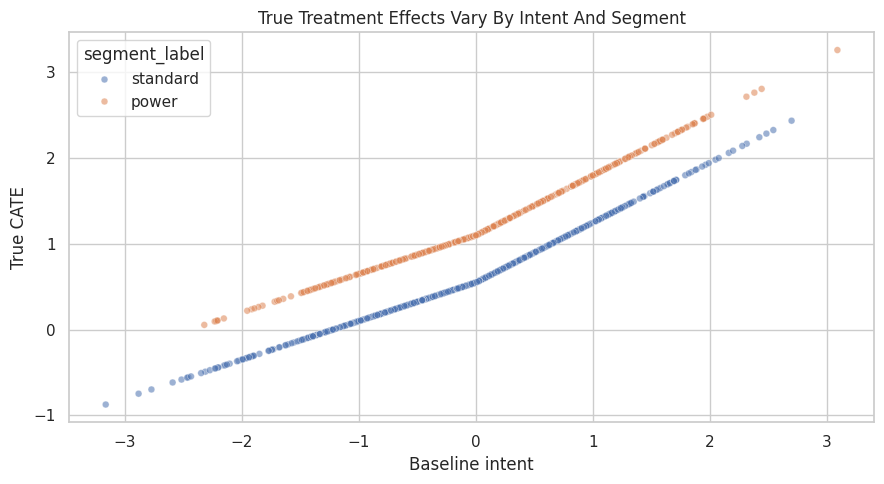

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=cate_df.sample(1_000, random_state=707),
    x="baseline_intent",
    y="true_cate",
    hue="segment_label",
    alpha=0.55,
    s=24,
    ax=ax,
)
ax.set_title("True Treatment Effects Vary By Intent And Segment")
ax.set_xlabel("Baseline intent")
ax.set_ylabel("True CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_true_cate_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

The effect rises with baseline intent, and the power segment sits above the standard segment. This is the pattern our estimators should recover if the model class is appropriate and the adjustment variables are sufficient.

## Ground-Truth CATE By Coarse Groups

Before fitting models, we summarize the true effect by segment and baseline-intent bucket. This gives us a simple target table to compare against later.

In [8]:
cate_df = cate_df.assign(
    intent_bucket=pd.qcut(
        cate_df["baseline_intent"],
        q=4,
        labels=["low intent", "mid-low intent", "mid-high intent", "high intent"],
    )
)

true_group_cate = (
    cate_df.groupby(["segment_label", "intent_bucket"], observed=True)
    .agg(
        rows=("weekly_value", "size"),
        exposure_rate=("recommendation_exposure", "mean"),
        mean_true_cate=("true_cate", "mean"),
        mean_outcome=("weekly_value", "mean"),
    )
    .reset_index()
)

true_group_cate.to_csv(TABLE_DIR / "07_true_group_cate.csv", index=False)
display(true_group_cate)

,segment_label,intent_bucket,rows,exposure_rate,mean_true_cate,mean_outcome
0,power,low intent,497,0.4245,0.5368,4.2689
1,power,mid-low intent,516,0.5911,0.9583,5.5047
2,power,mid-high intent,527,0.7021,1.3251,6.6154
3,power,high intent,564,0.8333,1.9720,8.2807
4,standard,low intent,753,0.3041,-0.0268,2.7305
5,standard,mid-low intent,734,0.4905,0.4085,4.0134
6,standard,mid-high intent,723,0.5878,0.7871,5.0240
7,standard,high intent,686,0.7347,1.4398,6.5231


The grouped truth table is a useful reference. Later, estimated CATE tables should show the same broad ordering: power segment above standard, high intent above low intent.

## Build The Causal Graph

The graph encodes the backdoor adjustment problem. Baseline intent, segment, seasonality, and prior value are all pre-treatment common causes of exposure and outcome. The graph does not need a special “effect modification arrow.” Effect modification is represented in the outcome model through treatment interactions.

In [9]:
def edges_to_dot(edges, graph_name="causal_graph"):
    edge_lines = [f"    {left} -> {right};" for left, right in edges]
    return "digraph " + graph_name + " {\n" + "\n".join(edge_lines) + "\n}"

cate_graph = edges_to_dot(
    [
        ("baseline_intent", "recommendation_exposure"),
        ("baseline_intent", "weekly_value"),
        ("power_segment", "recommendation_exposure"),
        ("power_segment", "weekly_value"),
        ("seasonality_score", "recommendation_exposure"),
        ("seasonality_score", "weekly_value"),
        ("prior_value", "recommendation_exposure"),
        ("prior_value", "weekly_value"),
        ("recommendation_exposure", "weekly_value"),
    ],
    graph_name="cate_graph",
)

print(cate_graph)

digraph cate_graph {
    baseline_intent -> recommendation_exposure;
    baseline_intent -> weekly_value;
    power_segment -> recommendation_exposure;
    power_segment -> weekly_value;
    seasonality_score -> recommendation_exposure;
    seasonality_score -> weekly_value;
    prior_value -> recommendation_exposure;
    prior_value -> weekly_value;
    recommendation_exposure -> weekly_value;
}


The graph says that the average effect can be identified by adjusting for the observed common causes. The heterogeneity analysis will reuse that same identified causal contrast and then model how the contrast changes across pre-treatment features.

## Create The DoWhy Model And Identify The Effect

This is the standard DoWhy workflow from earlier notebooks: create a `CausalModel`, then ask DoWhy to identify the causal effect. The estimand is still an ATE at this stage. CATE comes during estimation and reporting.

In [10]:
dowhy_columns = [
    "recommendation_exposure",
    "weekly_value",
    "baseline_intent",
    "power_segment",
    "seasonality_score",
    "prior_value",
]

cate_model = CausalModel(
    data=cate_df[dowhy_columns],
    treatment="recommendation_exposure",
    outcome="weekly_value",
    graph=cate_graph,
)
identified_estimand = cate_model.identify_effect(proceed_when_unidentifiable=True)

print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                  ↪
─────────────────────────(E[weekly_value|power_segment,baseline_intent,seasona ↪
d[recommendationₑₓₚₒₛᵤᵣₑ]                                                      ↪

↪                         
↪ lity_score,prior_value])
↪                         
Estimand assumption 1, Unconfoundedness: If U→{recommendation_exposure} and U→weekly_value then P(weekly_value|recommendation_exposure,power_segment,baseline_intent,seasonality_score,prior_value,U) = P(weekly_value|recommendation_exposure,power_segment,baseline_intent,seasonality_score,prior_value)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
            d                                               

DoWhy identifies a backdoor estimand using the observed common causes. This is the causal foundation for both the average effect and the heterogeneous effect summaries below.

## Estimate The Average Treatment Effect First

Before modeling heterogeneity, estimate the ATE. This gives us a baseline causal summary and a check against the known simulation truth.

In [11]:
ate_estimate = cate_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

naive_difference = (
    cate_df.loc[cate_df["recommendation_exposure"] == 1, "weekly_value"].mean()
    - cate_df.loc[cate_df["recommendation_exposure"] == 0, "weekly_value"].mean()
)

ate_comparison = pd.DataFrame(
    [
        {"quantity": "naive observed mean difference", "estimate": naive_difference},
        {"quantity": "DoWhy adjusted ATE", "estimate": ate_estimate.value},
        {"quantity": "true ATE", "estimate": true_ate},
    ]
)
ate_comparison["error_vs_truth"] = ate_comparison["estimate"] - true_ate

ate_comparison.to_csv(TABLE_DIR / "07_ate_comparison.csv", index=False)
display(ate_comparison)

,quantity,estimate,error_vs_truth
0,naive observed mean difference,2.2121,1.3305
1,DoWhy adjusted ATE,0.8391,-0.0426
2,true ATE,0.8816,0.0000


The adjusted ATE should be much closer to the true ATE than the naive difference. That gives us confidence that the graph and adjustment variables are doing useful work before we ask a harder heterogeneity question.

## Add Effect Modifiers To The DoWhy Linear Estimator

DoWhy's linear regression estimator can include treatment interactions with effect modifiers. Here we mark `baseline_intent` and `power_segment` as effect modifiers. They are also adjustment variables, which is allowed: they help block confounding and help explain variation in effect size.

We turn off automatic conditional estimates in this cell because we will compute subgroup effects explicitly. That keeps the grouping logic transparent and avoids hiding important choices about buckets.

In [12]:
linear_cate_estimate = cate_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    effect_modifiers=["baseline_intent", "power_segment"],
    method_params={"init_params": {"need_conditional_estimates": False}},
)

linear_cate_summary = pd.DataFrame(
    [
        {"quantity": "DoWhy linear CATE model average effect", "estimate": linear_cate_estimate.value},
        {"quantity": "true ATE", "estimate": true_ate},
    ]
)
linear_cate_summary["error_vs_truth"] = linear_cate_summary["estimate"] - true_ate

print(linear_cate_estimate.realized_estimand_expr)
display(linear_cate_summary)

b: weekly_value~recommendation_exposure+power_segment+baseline_intent+seasonality_score+prior_value+recommendation_exposure*baseline_intent+recommendation_exposure*power_segment


,quantity,estimate,error_vs_truth
0,DoWhy linear CATE model average effect,0.9091,0.0274
1,true ATE,0.8816,0.0000


The realized estimator expression includes treatment interactions. Those interactions are what allow the estimated treatment effect to vary across baseline intent and segment.

## Helper For Subgroup Effects

The fitted DoWhy estimator can compute the treatment contrast on any subset of rows by comparing predicted outcomes under treatment and control. This helper uses the already-fitted estimator and returns the average contrast for a provided slice.

In [13]:
def estimate_effect_for_slice(estimate, data_slice):
    """Use a fitted DoWhy estimator to estimate the average treatment effect inside a slice."""
    if len(data_slice) == 0:
        return np.nan
    return estimate.estimator.estimate_effect(
        data_slice[dowhy_columns],
        treatment_value=1,
        control_value=0,
        need_conditional_estimates=False,
    ).value

# Quick smoke test on the full data: this should match the average effect from the fitted linear CATE model.
full_slice_effect = estimate_effect_for_slice(linear_cate_estimate, cate_df)
print(f"Full-sample effect from slice helper: {full_slice_effect:.3f}")
print(f"Stored linear CATE model average effect: {linear_cate_estimate.value:.3f}")

Full-sample effect from slice helper: 0.909
Stored linear CATE model average effect: 0.909


The helper returns the same full-sample effect as the stored estimate. Now we can use it for interpretable subgroup summaries.

## Segment-Level CATE

The first heterogeneity view compares the estimated effect for standard and power users. This is intentionally simple: before showing individual-level scores, it is better to verify that coarse groups move in the expected direction.

In [14]:
segment_effect_rows = []
for segment_label, group in cate_df.groupby("segment_label"):
    segment_effect_rows.append(
        {
            "segment_label": segment_label,
            "rows": len(group),
            "exposure_rate": group["recommendation_exposure"].mean(),
            "estimated_cate": estimate_effect_for_slice(linear_cate_estimate, group),
            "true_cate": group["true_cate"].mean(),
        }
    )

segment_cate_table = pd.DataFrame(segment_effect_rows)
segment_cate_table["error_vs_truth"] = segment_cate_table["estimated_cate"] - segment_cate_table["true_cate"]
segment_cate_table.to_csv(TABLE_DIR / "07_segment_cate_linear.csv", index=False)
display(segment_cate_table)

,segment_label,rows,exposure_rate,estimated_cate,true_cate,error_vs_truth
0,power,2104,0.6445,1.2207,1.2223,-0.0016
1,standard,2896,0.5242,0.6826,0.6341,0.0485


The estimated segment effects should preserve the main pattern: power users have a larger treatment effect than standard users. The table also shows exposure rates, because subgroup effects are less credible when one subgroup has little treated or untreated support.

## Intent-Bucket CATE

Now we estimate CATE by baseline-intent quartile. Bucketed effects are less granular than individual scores, but they are easier to explain and audit.

In [15]:
intent_effect_rows = []
for intent_bucket, group in cate_df.groupby("intent_bucket", observed=True):
    intent_effect_rows.append(
        {
            "intent_bucket": intent_bucket,
            "rows": len(group),
            "exposure_rate": group["recommendation_exposure"].mean(),
            "estimated_cate": estimate_effect_for_slice(linear_cate_estimate, group),
            "true_cate": group["true_cate"].mean(),
        }
    )

intent_cate_table = pd.DataFrame(intent_effect_rows)
intent_cate_table["error_vs_truth"] = intent_cate_table["estimated_cate"] - intent_cate_table["true_cate"]
intent_cate_table.to_csv(TABLE_DIR / "07_intent_bucket_cate_linear.csv", index=False)
display(intent_cate_table)

,intent_bucket,rows,exposure_rate,estimated_cate,true_cate,error_vs_truth
0,low intent,1250,0.3520,0.1266,0.1972,-0.0706
1,mid-low intent,1250,0.5320,0.7133,0.6355,0.0778
2,mid-high intent,1250,0.6360,1.1094,1.0139,0.0955
3,high intent,1250,0.7792,1.6869,1.6799,0.0070


The estimated CATE should rise from low intent to high intent. This is the first check that the effect-modifier model is learning the intended slope.

## Two-Way CATE Table

Many heterogeneity stories are two-dimensional. Here we cross segment with intent bucket. This table is especially useful for communication because it shows both sources of variation at once.

In [16]:
two_way_rows = []
for (segment_label, intent_bucket), group in cate_df.groupby(["segment_label", "intent_bucket"], observed=True):
    two_way_rows.append(
        {
            "segment_label": segment_label,
            "intent_bucket": intent_bucket,
            "rows": len(group),
            "exposure_rate": group["recommendation_exposure"].mean(),
            "estimated_cate": estimate_effect_for_slice(linear_cate_estimate, group),
            "true_cate": group["true_cate"].mean(),
        }
    )

two_way_cate_table = pd.DataFrame(two_way_rows)
two_way_cate_table["error_vs_truth"] = two_way_cate_table["estimated_cate"] - two_way_cate_table["true_cate"]
two_way_cate_table.to_csv(TABLE_DIR / "07_two_way_cate_linear.csv", index=False)
display(two_way_cate_table)

,segment_label,intent_bucket,rows,exposure_rate,estimated_cate,true_cate,error_vs_truth
0,power,low intent,497,0.4245,0.4367,0.5368,-0.1001
1,power,mid-low intent,516,0.5911,1.0046,0.9583,0.0463
2,power,mid-high intent,527,0.7021,1.3905,1.3251,0.0654
3,power,high intent,564,0.8333,1.9508,1.9720,-0.0212
4,standard,low intent,753,0.3041,-0.0780,-0.0268,-0.0512
5,standard,mid-low intent,734,0.4905,0.5085,0.4085,0.1000
6,standard,mid-high intent,723,0.5878,0.9045,0.7871,0.1175
7,standard,high intent,686,0.7347,1.4699,1.4398,0.0301


The two-way view should show a ladder: higher intent increases the effect within each segment, and the power segment is higher within each intent bucket.

## Plot Linear CATE By Group

A grouped bar chart makes the two-way CATE pattern easier to scan. We plot estimated and true CATE side by side so the model's misses are visible.

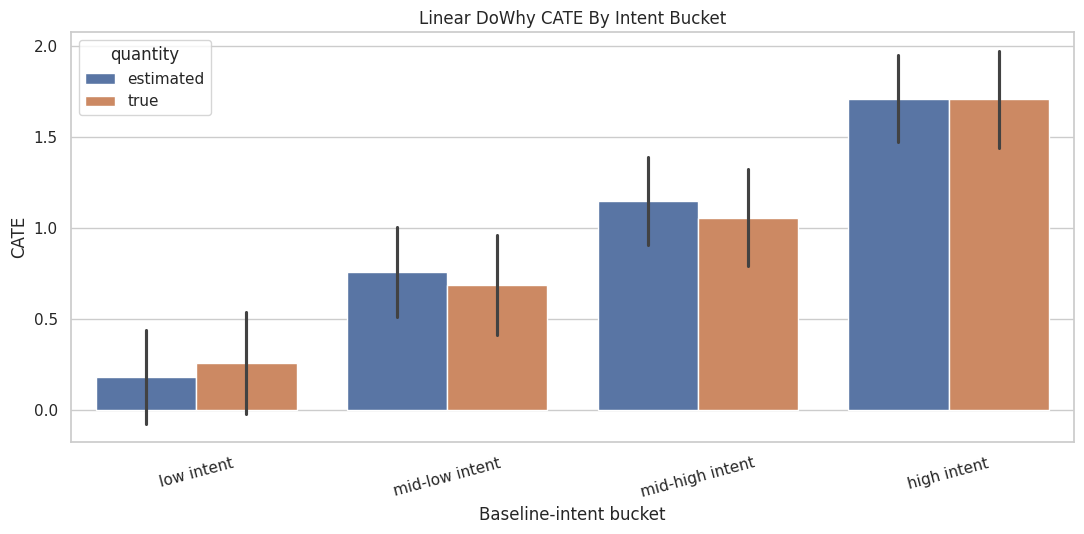

In [17]:
plot_two_way = two_way_cate_table.melt(
    id_vars=["segment_label", "intent_bucket", "rows", "exposure_rate"],
    value_vars=["estimated_cate", "true_cate"],
    var_name="quantity",
    value_name="cate",
)
plot_two_way["quantity"] = plot_two_way["quantity"].map(
    {"estimated_cate": "estimated", "true_cate": "true"}
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=plot_two_way,
    x="intent_bucket",
    y="cate",
    hue="quantity",
    ax=ax,
)
ax.set_title("Linear DoWhy CATE By Intent Bucket")
ax.set_xlabel("Baseline-intent bucket")
ax.set_ylabel("CATE")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_linear_cate_by_intent_bucket.png", dpi=160, bbox_inches="tight")
plt.show()

The linear model captures the broad monotonic pattern. It may still miss nonlinear details, especially at high baseline intent where the true effect contains an extra positive bend.

## DoWhy's Built-In Conditional Estimates For A Numeric Modifier

DoWhy can also compute conditional estimates automatically for numeric effect modifiers by splitting them into quantile bins. Here we ask for conditional estimates over `baseline_intent` only. We keep this example one-dimensional so the output is easy to read.

In [18]:
intent_only_estimate = cate_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    effect_modifiers=["baseline_intent"],
    method_params={
        "init_params": {
            "need_conditional_estimates": True,
            "num_quantiles_to_discretize_cont_cols": 4,
        }
    },
)

dowhy_conditional_intent = (
    intent_only_estimate.conditional_estimates
    .rename("dowhy_conditional_estimate")
    .reset_index()
    .rename(columns={"__categorical__baseline_intent": "baseline_intent_bin"})
)

dowhy_conditional_intent.to_csv(TABLE_DIR / "07_dowhy_conditional_intent.csv", index=False)
display(dowhy_conditional_intent)

,baseline_intent_bin,dowhy_conditional_estimate
0,"(-3.9539999999999997, -0.669]",0.1302
1,"(-0.669, 0.0162]",0.7072
2,"(0.0162, 0.674]",1.0975
3,"(0.674, 3.646]",1.6582


The automatic conditional estimates are useful for quick exploration. For reporting, it is often better to create named buckets yourself so the table labels are stable and easier to explain.

## Individual Effect Scores From The Linear CATE Model

A CATE model can score each row by comparing predicted outcomes under treatment and control. These row-level scores are not observed facts; they are model-based estimates. In this simulation, we can compare them to `true_cate` to see how well the model is doing.

In [19]:
linear_treated_outcome = linear_cate_estimate.estimator.interventional_outcomes(cate_df[dowhy_columns], 1)
linear_control_outcome = linear_cate_estimate.estimator.interventional_outcomes(cate_df[dowhy_columns], 0)
cate_df["linear_cate_score"] = np.asarray(linear_treated_outcome) - np.asarray(linear_control_outcome)

linear_score_metrics = pd.DataFrame(
    [
        {
            "model": "DoWhy linear effect-modifier model",
            "rmse_vs_true_cate": mean_squared_error(cate_df["true_cate"], cate_df["linear_cate_score"]) ** 0.5,
            "correlation_vs_true_cate": cate_df[["true_cate", "linear_cate_score"]].corr().iloc[0, 1],
            "mean_estimated_cate": cate_df["linear_cate_score"].mean(),
            "mean_true_cate": cate_df["true_cate"].mean(),
        }
    ]
)

linear_score_metrics.to_csv(TABLE_DIR / "07_linear_cate_score_metrics.csv", index=False)
display(linear_score_metrics)

,model,rmse_vs_true_cate,correlation_vs_true_cate,mean_estimated_cate,mean_true_cate
0,DoWhy linear effect-modifier model,0.0897,0.9917,0.9091,0.8816


The correlation and RMSE summarize how well the linear CATE score tracks the true treatment effect. A good average effect can coexist with weaker individual ranking, so both checks are useful.

## Linear CATE Calibration Plot

This scatterplot compares estimated and true row-level effects. The diagonal line marks perfect agreement. Because there are many points, we sample a subset for readability.

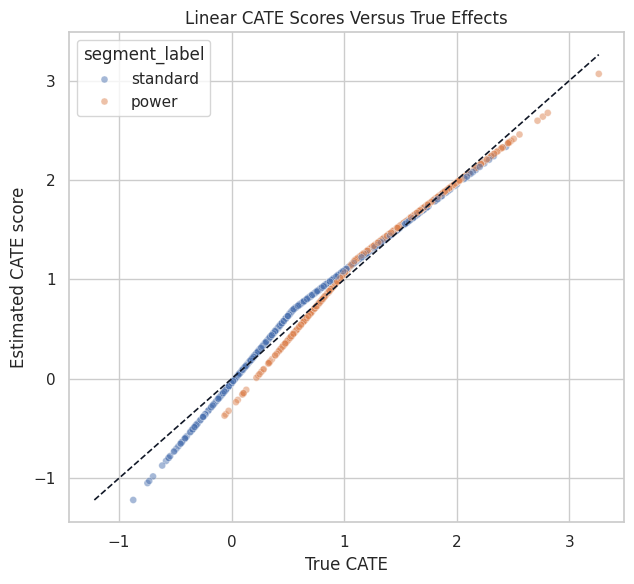

In [20]:
calibration_sample = cate_df.sample(1_200, random_state=707)

fig, ax = plt.subplots(figsize=(6.5, 6))
sns.scatterplot(
    data=calibration_sample,
    x="true_cate",
    y="linear_cate_score",
    hue="segment_label",
    alpha=0.50,
    s=25,
    ax=ax,
)
lims = [
    min(calibration_sample["true_cate"].min(), calibration_sample["linear_cate_score"].min()),
    max(calibration_sample["true_cate"].max(), calibration_sample["linear_cate_score"].max()),
]
ax.plot(lims, lims, linestyle="--", color="#111827", linewidth=1.2)
ax.set_title("Linear CATE Scores Versus True Effects")
ax.set_xlabel("True CATE")
ax.set_ylabel("Estimated CATE score")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_linear_cate_calibration_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

The linear model should rank effects reasonably well, but the shape may be too simple for the nonlinear high-intent region. That motivates trying a more flexible CATE model.

## Flexible CATE With DoWhy And EconML

DoWhy can call EconML estimators through method names such as `backdoor.econml.dml.CausalForestDML`. This keeps the causal graph and identification step in DoWhy while using a flexible estimator for heterogeneous effects.

A causal forest is useful when treatment effects vary nonlinearly or through feature interactions. It is also easier to overfit than a simple linear interaction model, so we will evaluate it rather than assume it is better.

In [21]:
forest_features = ["baseline_intent", "power_segment", "seasonality_score", "prior_value"]

forest_method_params = {
    "init_params": {
        "model_y": RandomForestRegressor(
            n_estimators=80,
            min_samples_leaf=20,
            random_state=711,
            n_jobs=-1,
        ),
        "model_t": RandomForestClassifier(
            n_estimators=80,
            min_samples_leaf=20,
            random_state=712,
            n_jobs=-1,
        ),
        "discrete_treatment": True,
        "n_estimators": 160,
        "min_samples_leaf": 25,
        "max_depth": 8,
        "random_state": 713,
        "n_jobs": -1,
    },
    "fit_params": {},
}

forest_cate_estimate = cate_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.CausalForestDML",
    effect_modifiers=forest_features,
    method_params=forest_method_params,
)

forest_summary = pd.DataFrame(
    [
        {"quantity": "DoWhy + EconML causal forest average effect", "estimate": forest_cate_estimate.value},
        {"quantity": "true ATE", "estimate": true_ate},
    ]
)
forest_summary["error_vs_truth"] = forest_summary["estimate"] - true_ate

display(forest_summary)

,quantity,estimate,error_vs_truth
0,DoWhy + EconML causal forest average effect,0.9069,0.0253
1,true ATE,0.8816,0.0000


The forest average effect should be close to the true ATE. The main reason to fit the forest is not the average, though; it is the possibility of better effect ranking when the true CATE is nonlinear.

## Score Rows With The Causal Forest

The fitted EconML estimator exposes an `effect` method. We pass the same effect-modifier features used during fitting and store the resulting CATE score.

In [22]:
forest_X = cate_df[forest_features]
cate_df["forest_cate_score"] = forest_cate_estimate.estimator.estimator.effect(forest_X)

model_score_metrics = pd.DataFrame(
    [
        {
            "model": "DoWhy linear effect-modifier model",
            "rmse_vs_true_cate": mean_squared_error(cate_df["true_cate"], cate_df["linear_cate_score"]) ** 0.5,
            "correlation_vs_true_cate": cate_df[["true_cate", "linear_cate_score"]].corr().iloc[0, 1],
            "mean_estimated_cate": cate_df["linear_cate_score"].mean(),
            "mean_true_cate": cate_df["true_cate"].mean(),
        },
        {
            "model": "DoWhy + EconML causal forest",
            "rmse_vs_true_cate": mean_squared_error(cate_df["true_cate"], cate_df["forest_cate_score"]) ** 0.5,
            "correlation_vs_true_cate": cate_df[["true_cate", "forest_cate_score"]].corr().iloc[0, 1],
            "mean_estimated_cate": cate_df["forest_cate_score"].mean(),
            "mean_true_cate": cate_df["true_cate"].mean(),
        },
    ]
)

model_score_metrics.to_csv(TABLE_DIR / "07_cate_model_score_metrics.csv", index=False)
display(model_score_metrics)

,model,rmse_vs_true_cate,correlation_vs_true_cate,mean_estimated_cate,mean_true_cate
0,DoWhy linear effect-modifier model,0.0897,0.9917,0.9091,0.8816
1,DoWhy + EconML causal forest,0.2395,0.9454,0.9069,0.8816


The forest usually improves row-level ranking and nonlinear fit, while the linear model remains easier to explain. This is a familiar tradeoff: flexibility can improve CATE scoring, but it also raises the bar for diagnostics.

## Compare Linear And Forest CATE Scores

The next plot compares both model scores against the true CATE. It is a compact way to see whether the flexible model is adding useful signal.

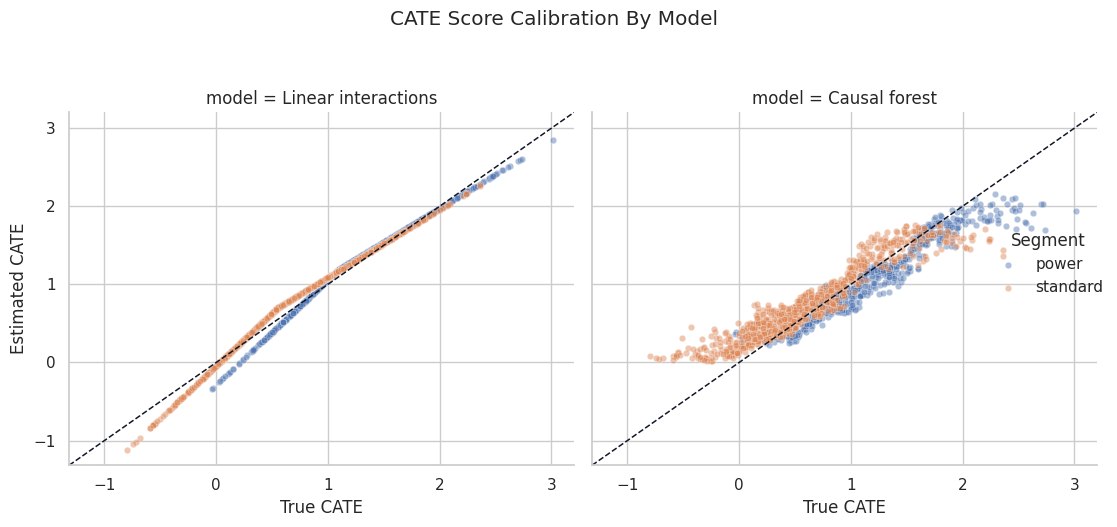

In [23]:
score_plot = cate_df.sample(1_400, random_state=717).melt(
    id_vars=["true_cate", "segment_label"],
    value_vars=["linear_cate_score", "forest_cate_score"],
    var_name="model",
    value_name="estimated_cate",
)
score_plot["model"] = score_plot["model"].map(
    {
        "linear_cate_score": "Linear interactions",
        "forest_cate_score": "Causal forest",
    }
)

g = sns.FacetGrid(score_plot, col="model", hue="segment_label", height=5, aspect=1.0, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="true_cate", y="estimated_cate", alpha=0.45, s=22)
for ax in g.axes.flat:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    low = min(xlim[0], ylim[0])
    high = max(xlim[1], ylim[1])
    ax.plot([low, high], [low, high], linestyle="--", color="#111827", linewidth=1.1)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
g.add_legend(title="Segment")
g.set_axis_labels("True CATE", "Estimated CATE")
g.fig.suptitle("CATE Score Calibration By Model", y=1.05)
plt.tight_layout()
g.fig.savefig(FIGURE_DIR / "07_linear_vs_forest_cate_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

The diagonal reference line makes underestimation and overestimation visible. The forest can bend with the nonlinear region, while the linear model is constrained to a simpler shape.

## CATE Ranking And Targeting Diagnostics

A common use of CATE models is prioritization: focus treatment where the expected causal gain is largest. In this simulation, we can check whether higher predicted-effect groups truly have higher effects.

We will create quintiles based on each model's estimated CATE score and compare the average true CATE inside each quintile.

In [24]:
def make_score_quintile_table(data, score_col, label):
    temp = data.copy()
    temp["score_quintile"] = pd.qcut(
        temp[score_col],
        q=5,
        labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
        duplicates="drop",
    )
    out = (
        temp.groupby("score_quintile", observed=True)
        .agg(
            rows=("weekly_value", "size"),
            mean_score=(score_col, "mean"),
            mean_true_cate=("true_cate", "mean"),
            exposure_rate=("recommendation_exposure", "mean"),
        )
        .reset_index()
    )
    out["model"] = label
    return out

ranking_table = pd.concat(
    [
        make_score_quintile_table(cate_df, "linear_cate_score", "Linear interactions"),
        make_score_quintile_table(cate_df, "forest_cate_score", "Causal forest"),
    ],
    ignore_index=True,
)

ranking_table.to_csv(TABLE_DIR / "07_cate_ranking_by_quintile.csv", index=False)
display(ranking_table)

,score_quintile,rows,mean_score,mean_true_cate,exposure_rate,model
0,Q1 lowest,1000,-0.0148,0.0472,0.3240,Linear interactions
1,Q2,1000,0.5562,0.4997,0.4810,Linear interactions
2,Q3,1000,0.9101,0.8293,0.5750,Linear interactions
3,Q4,1000,1.2632,1.1922,0.6870,Linear interactions
4,Q5 highest,1000,1.8306,1.8398,0.8070,Linear interactions
5,Q1 lowest,1000,0.2801,0.0955,0.3220,Causal forest
6,Q2,1000,0.5772,0.4928,0.4740,Causal forest
7,Q3,1000,0.8306,0.8161,0.5770,Causal forest
8,Q4,1000,1.1739,1.2082,0.7110,Causal forest
9,Q5 highest,1000,1.6728,1.7956,0.7900,Causal forest


A useful CATE model should produce a rising `mean_true_cate` from the lowest to highest score quintile. This is a targeting diagnostic, not a proof of validity, but it is very helpful when ground truth or experimental validation is available.

## Plot CATE Ranking Quality

The line chart below shows whether higher predicted CATE buckets correspond to higher true effects. This is often easier to communicate than a dense individual-level scatterplot.

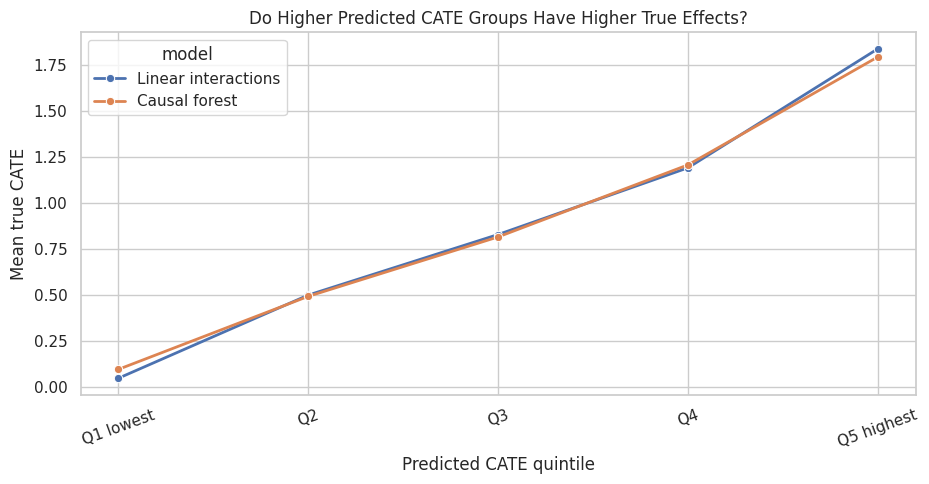

In [25]:
fig, ax = plt.subplots(figsize=(9.5, 5))
sns.lineplot(
    data=ranking_table,
    x="score_quintile",
    y="mean_true_cate",
    hue="model",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Do Higher Predicted CATE Groups Have Higher True Effects?")
ax.set_xlabel("Predicted CATE quintile")
ax.set_ylabel("Mean true CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_cate_ranking_quality.png", dpi=160, bbox_inches="tight")
plt.show()

The best pattern is a clear upward slope. If the line is flat, the model may estimate the average effect well but fail to rank units by treatment-effect size.

## Overlap By Predicted CATE Group

CATE models can create confident-looking scores in regions with poor treatment overlap. The next diagnostic estimates a simple propensity model, then summarizes propensity and exposure rates by predicted CATE quintile.

This does not replace the causal graph, but it helps reveal whether the highest-score groups have both treated and untreated examples.

In [26]:
propensity_features = ["baseline_intent", "power_segment", "seasonality_score", "prior_value"]
propensity_model = LogisticRegression(max_iter=1_000)
propensity_model.fit(cate_df[propensity_features], cate_df["recommendation_exposure"])
cate_df["estimated_propensity"] = propensity_model.predict_proba(cate_df[propensity_features])[:, 1]
propensity_auc = roc_auc_score(cate_df["recommendation_exposure"], cate_df["estimated_propensity"])

cate_df["forest_score_quintile"] = pd.qcut(
    cate_df["forest_cate_score"],
    q=5,
    labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
    duplicates="drop",
)

overlap_by_cate_group = (
    cate_df.groupby("forest_score_quintile", observed=True)
    .agg(
        rows=("weekly_value", "size"),
        exposure_rate=("recommendation_exposure", "mean"),
        mean_propensity=("estimated_propensity", "mean"),
        min_propensity=("estimated_propensity", "min"),
        max_propensity=("estimated_propensity", "max"),
        mean_forest_cate=("forest_cate_score", "mean"),
        mean_true_cate=("true_cate", "mean"),
    )
    .reset_index()
)

overlap_by_cate_group.to_csv(TABLE_DIR / "07_overlap_by_forest_cate_group.csv", index=False)
print(f"Simple propensity model AUC: {propensity_auc:.3f}")
display(overlap_by_cate_group)

Simple propensity model AUC: 0.726


,forest_score_quintile,rows,exposure_rate,mean_propensity,min_propensity,max_propensity,mean_forest_cate,mean_true_cate
0,Q1 lowest,1000,0.3220,0.3108,0.0252,0.5575,0.2801,0.0955
1,Q2,1000,0.4740,0.4722,0.2145,0.7203,0.5772,0.4928
2,Q3,1000,0.5770,0.5917,0.3421,0.8415,0.8306,0.8161
3,Q4,1000,0.7110,0.7066,0.3267,0.9239,1.1739,1.2082
4,Q5 highest,1000,0.7900,0.7926,0.5029,0.9643,1.6728,1.7956


The table checks whether the highest predicted-effect group still has real treatment variation. If a group is almost entirely treated or untreated, its CATE estimate leans heavily on extrapolation.

## Plot Propensity Distributions Across Forest CATE Groups

The boxplot below shows estimated propensity by CATE quintile. It helps catch a common problem: the model's “best treatment group” may also be a group where treatment assignment was nearly deterministic.

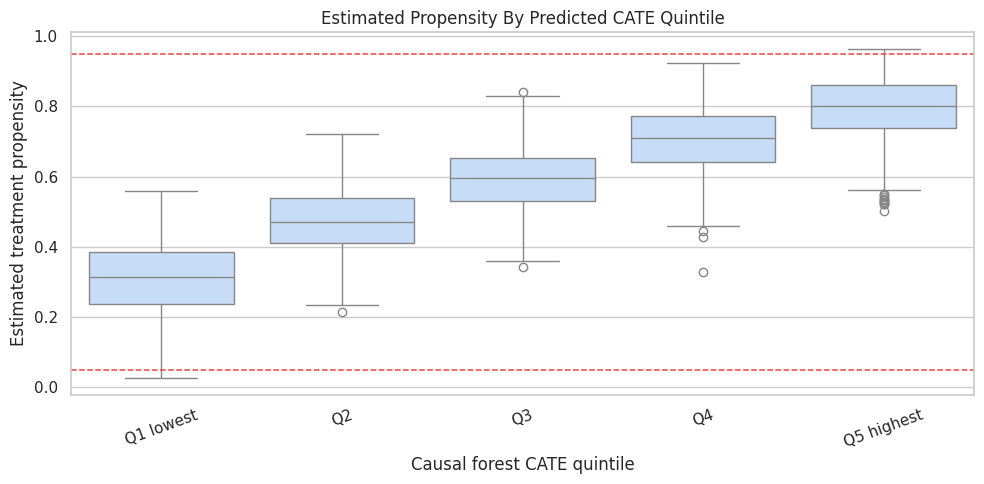

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=cate_df,
    x="forest_score_quintile",
    y="estimated_propensity",
    color="#bfdbfe",
    ax=ax,
)
ax.axhline(0.05, color="#ef4444", linestyle="--", linewidth=1.1)
ax.axhline(0.95, color="#ef4444", linestyle="--", linewidth=1.1)
ax.set_title("Estimated Propensity By Predicted CATE Quintile")
ax.set_xlabel("Causal forest CATE quintile")
ax.set_ylabel("Estimated treatment propensity")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "07_propensity_by_cate_quintile.png", dpi=160, bbox_inches="tight")
plt.show()

The dashed lines mark very rough danger zones. In real work, poor overlap should trigger trimming, redesigned analysis, or more cautious claims about the affected region.

## Model Comparison Summary

This final table compares the average effect, row-level score quality, and targeting quality for the linear and forest CATE approaches. The targeting lift here is computed as the true CATE in the highest score quintile minus the population true ATE.

In [28]:
def targeting_lift(data, score_col):
    quintile = pd.qcut(
        data[score_col],
        q=5,
        labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
        duplicates="drop",
    )
    top_group = data.loc[quintile == "Q5 highest"]
    return top_group["true_cate"].mean() - data["true_cate"].mean()

final_model_comparison = pd.DataFrame(
    [
        {
            "model": "Linear interactions",
            "average_effect_estimate": linear_cate_estimate.value,
            "rmse_vs_true_cate": mean_squared_error(cate_df["true_cate"], cate_df["linear_cate_score"]) ** 0.5,
            "correlation_vs_true_cate": cate_df[["true_cate", "linear_cate_score"]].corr().iloc[0, 1],
            "top_quintile_true_cate_lift": targeting_lift(cate_df, "linear_cate_score"),
        },
        {
            "model": "Causal forest",
            "average_effect_estimate": forest_cate_estimate.value,
            "rmse_vs_true_cate": mean_squared_error(cate_df["true_cate"], cate_df["forest_cate_score"]) ** 0.5,
            "correlation_vs_true_cate": cate_df[["true_cate", "forest_cate_score"]].corr().iloc[0, 1],
            "top_quintile_true_cate_lift": targeting_lift(cate_df, "forest_cate_score"),
        },
    ]
)
final_model_comparison["true_ate"] = true_ate
final_model_comparison["average_effect_error"] = final_model_comparison["average_effect_estimate"] - true_ate

final_model_comparison.to_csv(TABLE_DIR / "07_final_cate_model_comparison.csv", index=False)
display(final_model_comparison)

,model,average_effect_estimate,rmse_vs_true_cate,correlation_vs_true_cate,top_quintile_true_cate_lift,true_ate,average_effect_error
0,Linear interactions,0.9091,0.0897,0.9917,0.9582,0.8816,0.0274
1,Causal forest,0.9069,0.2395,0.9454,0.9140,0.8816,0.0253


The better CATE model is not always the model with the best average effect. For heterogeneity work, ranking and subgroup calibration matter because the model may be used to decide where treatment is most valuable.

## Practical CATE Checklist

Use this checklist when moving from tutorial data to real data:

- Make the causal graph and adjustment set explicit before modeling heterogeneity.
- Use only pre-treatment variables as effect modifiers.
- Start with interpretable subgroup CATE tables before showing individual scores.
- Check treatment overlap inside the subgroups that drive the story.
- Compare simple and flexible CATE models; do not assume complexity wins.
- Validate CATE ranking with experiments, holdout randomized data, or domain-specific stress tests whenever possible.
- Report uncertainty and limitations, especially for small or poorly supported subgroups.

## Practice Prompts

Try these extensions after running the notebook:

1. Remove `baseline_intent` from the adjustment set but keep it as an effect modifier. How do the ATE and CATE summaries change?
2. Increase the nonlinear term in `true_cate`. Does the causal forest pull farther ahead of the linear model?
3. Make treatment assignment nearly deterministic for high-intent users. What happens to the overlap diagnostics?
4. Replace quintiles with deciles. Which CATE summaries become noisier?
5. Create a final one-page stakeholder summary that reports the ATE, two subgroup effects, and the main overlap limitation.

## What Comes Next

The next tutorial focuses on refuters, placebos, negative controls, and sensitivity checks. That is the natural follow-up: once we estimate an effect or a pattern of heterogeneous effects, we need to ask how fragile the result is to alternative explanations.